# Decision trees - Binary Classification

Note

In this class we attempt to follow the same flow (whenever possible or applicable) to ensure proper pipelines
* 0. Setup
* 1. Data Loading and Exploration
* 2. Data Processing
* 3. Model Building
* 4. Evaluation

## 0. Setup

In this notebook, we'll explore Decision Trees for classification using the Palmer Penguins dataset.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

## 1. Data Loading and Exploration

Let's start by loading our dataset and exploring its characteristics.

### The Data

We are going to use the 'Palmer Penguins' dataset because penguins are funny creatures. More info can be found at https://www.kaggle.com/datasets/parulpandey/palmer-archipelago-antarctica-penguin-data

<img src="penguin.jpg" style="max-width:400px">


Summary:
The data folder contains two CSV files. For intro courses/examples, you probably want to use the first one (penguins_size.csv).

* penguins_size.csv: Simplified data from original penguin data sets. Contains variables:

    * species: penguin species (Chinstrap, Adélie, or Gentoo)
    * culmen_length_mm: culmen length (mm)
    * culmen_depth_mm: culmen depth (mm)
    * flipper_length_mm: flipper length (mm)
    * body_mass_g: body mass (g)
    * island: island name (Dream, Torgersen, or Biscoe) in the Palmer Archipelago (Antarctica)
    * sex: penguin sex

* (Not used) penguins_lter.csv: Original combined data for 3 penguin species  

Note: The culmen is "the upper ridge of a bird's beak" 

**Our goal is to create a model that can help predict a species of a penguin based on physical attributes, then we can use that model to help researchers classify penguins in the field, instead of needing an experienced biologist**

In [5]:
# load the data
df = pd.read_csv("datasets/penguins_size.csv")

In [6]:
# get the information (info) about the data
df.head()

,species,island,culmen_length_mm,culmen_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,MALE
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,FEMALE
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,FEMALE
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,FEMALE


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 344 entries, 0 to 343
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   species            344 non-null    object 
 1   island             344 non-null    object 
 2   culmen_length_mm   342 non-null    float64
 3   culmen_depth_mm    342 non-null    float64
 4   flipper_length_mm  342 non-null    float64
 5   body_mass_g        342 non-null    float64
 6   sex                334 non-null    object 
dtypes: float64(4), object(3)
memory usage: 18.9+ KB


In [9]:
# drop na
df = df.dropna()
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 334 entries, 0 to 343
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   species            334 non-null    object 
 1   island             334 non-null    object 
 2   culmen_length_mm   334 non-null    float64
 3   culmen_depth_mm    334 non-null    float64
 4   flipper_length_mm  334 non-null    float64
 5   body_mass_g        334 non-null    float64
 6   sex                334 non-null    object 
dtypes: float64(4), object(3)
memory usage: 20.9+ KB


Visualize the data using a pairplot

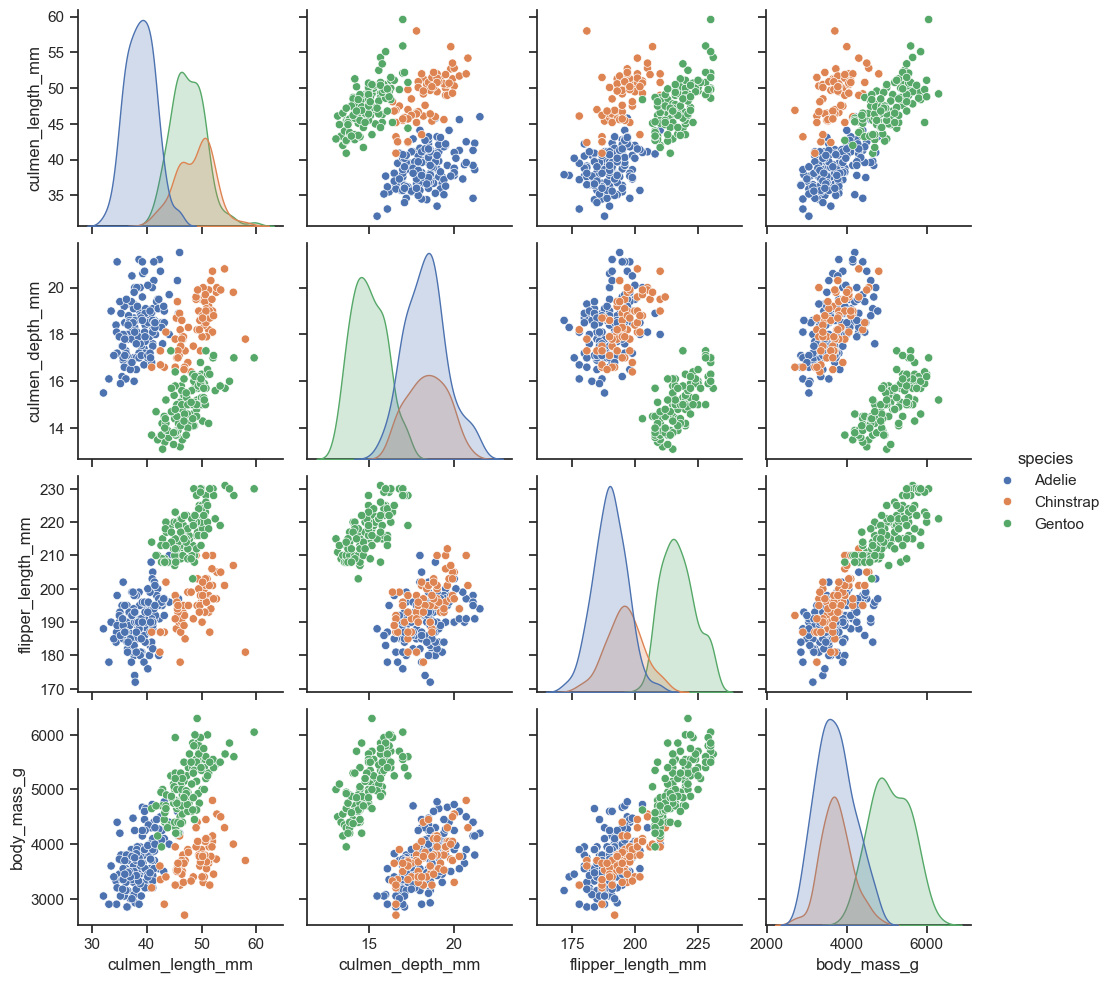

In [10]:
import seaborn as sns 
sns.set_theme(style="ticks")
sns.pairplot(df, hue="species")

In [11]:
# count values for each species
df['species'].value_counts()

species
Adelie       146
Gentoo       120
Chinstrap     68
Name: count, dtype: int64

## 2. Data Processing

Now that we've explored our data, let's prepare it for model training.

In [12]:
# create dummy variables and define X and y
X = pd.get_dummies(df.drop('species',axis=1),drop_first=True)
y = df['species']

In [13]:
X

,culmen_length_mm,culmen_depth_mm,flipper_length_mm,body_mass_g,island_Dream,island_Torgersen,sex_FEMALE,sex_MALE
0,39.1,18.7,181.0,3750.0,False,True,False,True
1,39.5,17.4,186.0,3800.0,False,True,True,False
2,40.3,18.0,195.0,3250.0,False,True,True,False
4,36.7,19.3,193.0,3450.0,False,True,True,False
5,39.3,20.6,190.0,3650.0,False,True,False,True
...,...,...,...,...,...,...,...,...
338,47.2,13.7,214.0,4925.0,False,False,True,False
340,46.8,14.3,215.0,4850.0,False,False,True,False
341,50.4,15.7,222.0,5750.0,False,False,False,True
342,45.2,14.8,212.0,5200.0,False,False,True,False


### Train | Test Split

In [15]:
from sklearn.model_selection import train_test_split

In [18]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=101)

X_train.head()

,culmen_length_mm,culmen_depth_mm,flipper_length_mm,body_mass_g,island_Dream,island_Torgersen,sex_FEMALE,sex_MALE
194,50.9,19.1,196.0,3550.0,True,False,False,True
22,35.9,19.2,189.0,3800.0,False,False,True,False
92,34.0,17.1,185.0,3400.0,True,False,True,False
149,37.8,18.1,193.0,3750.0,True,False,False,True
156,52.7,19.8,197.0,3725.0,True,False,False,True


## 3. Model Building

Let's build and train our Decision Tree model.

In [23]:
from sklearn.tree import DecisionTreeClassifier

In [25]:
Dtree = DecisionTreeClassifier()
Dtree.fit(X_train,y_train)


DecisionTreeClassifier()

In [26]:
preds = Dtree.predict(X_test)

## 4. Evaluation

In [27]:
from sklearn import tree

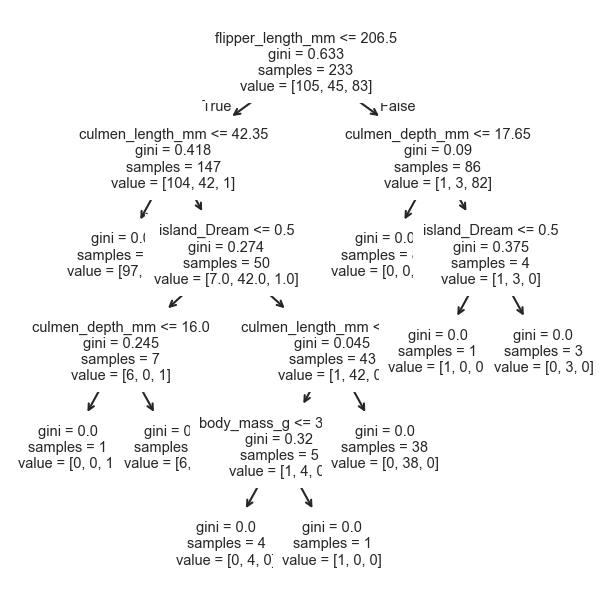

In [28]:
plt.figure(figsize = (5,5), dpi = 150)
tree.plot_tree(Dtree, fontsize = 7, 
               feature_names = ['culmen_length_mm', 'culmen_depth_mm', 
                                'flipper_length_mm','body_mass_g', 
                                'island_Dream', 'island_Torgersen', 
                                'sex_FEMALE','sex_MALE']);

In [29]:
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay, accuracy_score

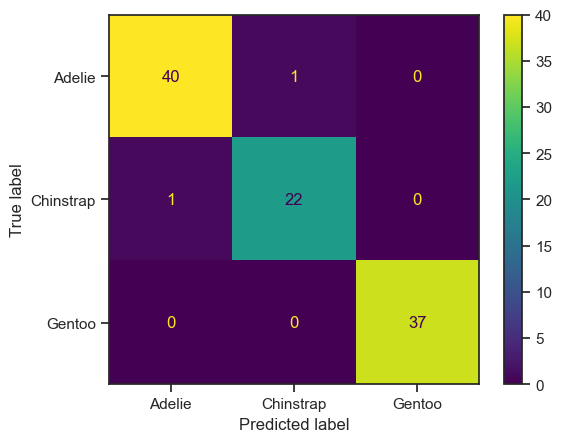

In [30]:
cm = confusion_matrix(y_test,preds)
CM_plot = ConfusionMatrixDisplay(confusion_matrix=cm, 
                                 display_labels=Dtree.classes_)
CM_plot.plot()

In [31]:
print("Accuracy Score:", accuracy_score(y_test, preds))
print("\nClassification Report:")
print(classification_report(y_test, preds))

Accuracy Score: 0.9801980198019802

Classification Report:
              precision    recall  f1-score   support

      Adelie       0.98      0.98      0.98        41
   Chinstrap       0.96      0.96      0.96        23
      Gentoo       1.00      1.00      1.00        37

    accuracy                           0.98       101
   macro avg       0.98      0.98      0.98       101
weighted avg       0.98      0.98      0.98       101



### Understanding the Metrics

Het classificatie rapport toont verschillende met betrekking tot elke soort pinguins: 

1. **Precision**: 
   - ...

2. **Recall**: 
   - ...

3. **F1-Score**:
   - ...

4. **Support**:
   - ...

# Random Forests

## 1. Data Loading and Exploration

In this section, we'll load and explore the Palmer Penguins dataset again. Remember this dataset contains physical measurements of three penguin species: Chinstrap, Adélie, and Gentoo.

In [ ]:
os.chdir()

In [ ]:
# load the .csv file
df = 

In [ ]:
# get the info

## 2. Data Processing

This section focuses on preparing our data for modeling. We'll perform the following steps:
1. Handle missing values
2. Convert categorical variables (using one-hot encoding)
3. Split the data into training and testing sets

In [2]:
# drop na and display the first 5 rows

In [ ]:
X = 
y = 

### Train | Test Split

In [ ]:
from sklearn.model_selection import train_test_split
...

## 3. Model Building

In this section, we'll create and train our Random Forest model. We'll explore:
1. Basic Random Forest implementation
2. Hyperparameter tuning
3. Model optimization through grid search

### Random Forest Classification

In [9]:
from sklearn.ensemble import RandomForestClassifier

In [ ]:
# use 10 random trees (n_estimators), set a random state and set max_features at 'sqrt'
model = 

In [ ]:
# fit the model
model


In [ ]:
# make the predictions
preds = model.predict(X_test)

## 4. Evaluation

This section focuses on evaluating our model's performance using various metrics:
1. Confusion Matrix
2. Classification Report
3. Feature Importance Analysis
4. Model Performance Analysis with different numbers of trees

In [13]:
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay, accuracy_score 

In [ ]:
# remember, it takes the labels that we kept for testing the model (y-test and compares it to the predicted labels (preds))
cm = 

In [ ]:
CM_plot = ConfusionMatrixDisplay(...)

In [ ]:
# Create a Classification report (like displayed in the report underneath)
print("Accuracy Score:"...)
print("\nClassification Report:")
print(...)

Accuracy Score: 0.9702970297029703

Classification Report:
              precision    recall  f1-score   support

      Adelie       0.97      0.95      0.96        41
   Chinstrap       0.92      0.96      0.94        23
      Gentoo       1.00      1.00      1.00        37

    accuracy                           0.97       101
   macro avg       0.96      0.97      0.97       101
weighted avg       0.97      0.97      0.97       101



### Feature Importance

Very useful attribute of the trained model

In [ ]:
# Get the feature importances (.feature_importances_)

In [ ]:
forest_importances = pd.DataFrame({"rfc": model.feature_importances_}, index=X.columns)
forest_importances.sort_values(by = 'rfc', ascending = False, inplace = True)

fig, ax = plt.subplots()
forest_importances.plot.bar(ax=ax)
ax.set_title("Feature importances using MDI")
ax.set_ylabel("Mean decrease in impurity")
fig.tight_layout()

### Choosing correct number of trees

Let's explore if continually adding more trees improves performance...

In [ ]:
test_error = []

for n in range(1, 40):
    # Use n random trees
    
 

In [ ]:
plt.plot()
...

### Model Performance Analysis

Het Random Forest model voor penguin classificatie heeft enkele interessante karakteristieken:

1. **Classification Performance**:
   - ...

2. **Feature Importance**:
   - ...

3. **Number of Trees Analysis**:
   - ...

4. **Advantages Over Single Decision Tree**:
   - ...

# Exercises Decision Trees and Random Forests

## Exercise 1. Random Forest Classifier

### 0. Setup

In [98]:
import pandas as pd
import numpy as np  
import matplotlib.pyplot as plt
import seaborn as sns
import os

### 1. Data Loading

In [ ]:
# print(os.getcwd())
# os.chdir('')

# for i in os.listdir():
#     if i.endswith('.csv'):
#         print(i)


In [ ]:
# load the data and display first 5 rows
data = 

### 2. Data Processing

In [ ]:
# get data info and get value_counts for all variables
data...

In [ ]:
# count the number of missing values in each column
data...

In [ ]:
# Use Simple Imputer to fill (fit and transform) missing values in Loan Amount Term
from sklearn.impute import SimpleImputer

imputer = 


In [ ]:
# recode 3+ in the variable Dependents to 3


In [ ]:
# drop rows with NA
data.dropna(inplace = True)

In [ ]:
# Use the LabelEncoder to convert categorical 'object' features
from sklearn.preprocessing import LabelEncoder
...

In [ ]:
# get info and describe the data again
...

#### Train | Test Split

In [ ]:
# Create a training and test set (try to predict loan status)
from sklearn.model_selection import train_test_split



#### Feature Scaling

In [ ]:
# Use the Standard Scaler to scale (fit and transform) the features for the training and test set
from sklearn.preprocessing import StandardScaler


### 3. Model Building

In [ ]:
# fit a random forest classifier (criterion = 'entropy' and set a random_state)
from sklearn.metrics import classification_report
from sklearn.ensemble import RandomForestClassifier

model = ...



RandomForestClassifier(criterion='entropy', random_state=42)

### 4. Evaluation

In [ ]:
preds = ...

In [ ]:
print(classification_report(...))

              precision    recall  f1-score   support

           0       1.00      0.42      0.59        31
           1       0.78      1.00      0.88        65

    accuracy                           0.81        96
   macro avg       0.89      0.71      0.73        96
weighted avg       0.85      0.81      0.79        96



In [ ]:
# print feature importances with their respective feature names

In [ ]:
# plot feature importances
forest_importances = pd.DataFrame({"rfc": model.feature_importances_}, index=X.columns)
forest_importances.sort_values(by = 'rfc', ascending = False, inplace = True)

fig, ax = plt.subplots()
forest_importances.plot.bar(ax=ax)

#### Conclusion
....

## Exercise 2. Random Forest Regressor

This housing dataset provides a thorough analysis of the current state of the housing market. It includes information on housing prices, availability, and key trends, allowing you to gain a better understanding of the market and make informed decisions. 

It is your goal to create a prediction model and actually predict the housing prices of the first five houses in the test set.

### 0. Setup

In [77]:
import pandas as pd
import numpy as np  
import matplotlib.pyplot as plt
import seaborn as sns
import os

In [ ]:
os.chdir("")

for i in os.listdir():
    print(i)

### 1. Data Loading

In [ ]:
melbourne_housing = 

In [ ]:
# drop na and get info
...

In [ ]:
...

### 2. Data Processing

In [ ]:
# Create a features dataframe including 'Rooms', 'Bathroom', 'Landsize', 'Lattitude', 'Longtitude' and a target dataframe 'Price'



#### Train | Test Split

In [ ]:
from sklearn.model_selection import train_test_split
...

In [ ]:
# describe the features data set
...

In [ ]:
X.head()

### 3. Model Building

In [86]:
from sklearn.tree import DecisionTreeRegressor

In [ ]:
# create and fit the model with random state 1)
model = 

In [ ]:
...

In [ ]:
preds = 

### 4. Evaluation

In [92]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


In [ ]:
# calculate the mean absolute error
...

In [ ]:
# calculate the mean squared error
...


In [ ]:
# calculate the r2 score
...

mean_absolute_error: Measures the average absolute difference between actual and predicted values. 

mean_squared_error: Measures the average of the squared differences. 

r2_score: Measures how well the predictions approximate the actual values..

### 5. Make predictions

Predict the house price for the first five houses in X

In [ ]:
print("Making predictions for the following 5 houses:")
...

Making predictions for the following 5 houses:
   Rooms  Bathroom  Landsize  Lattitude  Longtitude
1      2       1.0     156.0   -37.8079    144.9934
2      3       2.0     134.0   -37.8093    144.9944
4      4       1.0     120.0   -37.8072    144.9941
6      3       2.0     245.0   -37.8024    144.9993
7      2       1.0     256.0   -37.8060    144.9954
The predictions are
[ 905000. 1465000. 1600000. 1876000. 1636000.]
